In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
sns.set_style("whitegrid")

from pathlib import Path

# Exploratory Data Analysis (EDA)

1. Check Missing Values & Data Consistency

In [3]:
dataset_path = Path("research_centers.csv")

# research center quality dataframe 
rcq_df = pd.read_csv(dataset_path)

print("Research center quality data preview: \n", rcq_df.head(3))

Research center quality data preview: 
   researchCenterId  researchCenterName    city  latitude  longitude  \
0           RC-014  Research Center 14  City 4   50.7713    -1.9260   
1           RC-040  Research Center 40  City 2   50.5088    -1.3637   
2           RC-031  Research Center 31  City 4   50.2202    -1.2889   

   internalFacilitiesCount  hospitals_10km  pharmacies_10km  \
0                        3               1                0   
1                        2               1                1   
2                        3               0                1   

   facilityDiversity_10km  facilityDensity_10km  
0                0.374488              0.177506  
1                0.391903              0.108965  
2                0.293552              0.076155  


In [4]:
# Dataset info
print(rcq_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   researchCenterId         50 non-null     str    
 1   researchCenterName       50 non-null     str    
 2   city                     50 non-null     str    
 3   latitude                 50 non-null     float64
 4   longitude                50 non-null     float64
 5   internalFacilitiesCount  50 non-null     int64  
 6   hospitals_10km           50 non-null     int64  
 7   pharmacies_10km          50 non-null     int64  
 8   facilityDiversity_10km   50 non-null     float64
 9   facilityDensity_10km     50 non-null     float64
dtypes: float64(4), int64(3), str(3)
memory usage: 4.0 KB
None


In [5]:
# Describe data
print(rcq_df.describe())

        latitude  longitude  internalFacilitiesCount  hospitals_10km  \
count  50.000000  50.000000                50.000000       50.000000   
mean   50.542770  -1.554638                 5.660000        1.860000   
std     0.320289   0.253853                 3.146816        1.340271   
min    50.007100  -1.976900                 1.000000        0.000000   
25%    50.240375  -1.747225                 3.000000        1.000000   
50%    50.635350  -1.561000                 5.000000        2.000000   
75%    50.831475  -1.374175                 8.750000        3.000000   
max    50.994600  -1.049300                11.000000        4.000000   

       pharmacies_10km  facilityDiversity_10km  facilityDensity_10km  
count        50.000000               50.000000             50.000000  
mean          2.240000                0.568843              0.321164  
std           1.684988                0.249511              0.182562  
min           0.000000                0.119515              0.05654

In [6]:
rows, columms = rcq_df.shape
print(f"Dataset has {rows} rows, and {columms} columns")

print("\nDuplicates:", rcq_df.duplicated().sum())

print("\nPercentage of missing values per column:")
print(rcq_df.isnull().sum()/rows*100)

Dataset has 50 rows, and 10 columns

Duplicates: 0

Percentage of missing values per column:
researchCenterId           0.0
researchCenterName         0.0
city                       0.0
latitude                   0.0
longitude                  0.0
internalFacilitiesCount    0.0
hospitals_10km             0.0
pharmacies_10km            0.0
facilityDiversity_10km     0.0
facilityDensity_10km       0.0
dtype: float64


In [7]:
# Get all unquie values per column, exclude if value same as size of entries
for col in rcq_df.columns:
    unique_vals = rcq_df[col].unique()
    if len(unique_vals) != rows:
        print(f"Column: {col}")
        print(f"Unique values ({len(unique_vals)}): {unique_vals}\n")

Column: city
Unique values (5): <StringArray>
['City 4', 'City 2', 'City 5', 'City 3', 'City 1']
Length: 5, dtype: str

Column: internalFacilitiesCount
Unique values (11): [ 3  2 11 10  4  1  8  5  9  6  7]

Column: hospitals_10km
Unique values (5): [1 0 4 2 3]

Column: pharmacies_10km
Unique values (6): [0 1 4 5 3 2]



2. Visualize Facility Counts, Diversity, and Density

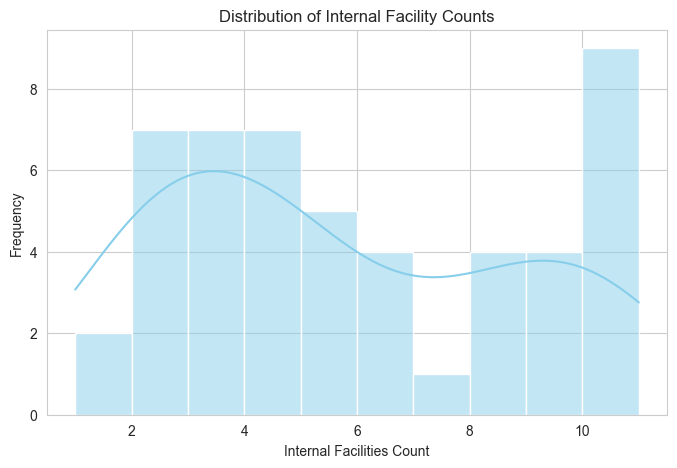

In [8]:
# Histogram of internal facility counts.
plt.figure(figsize=(8,5))
sns.histplot(rcq_df['internalFacilitiesCount'], bins=10, kde=True, color='skyblue')
plt.title("Distribution of Internal Facility Counts")
plt.xlabel("Internal Facilities Count")
plt.ylabel("Frequency")
plt.show()

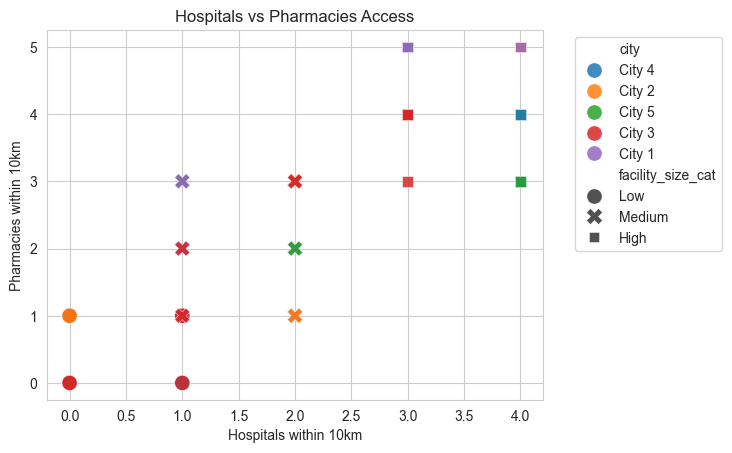

In [9]:
# Scatter plots showing hospital and pharmacy access
rcq_df_sp = rcq_df.copy()
rcq_df_sp["facility_size_cat"] = pd.cut(
    rcq_df_sp["internalFacilitiesCount"],
    bins=[0, 3, 7, 11],
    labels=["Low", "Medium", "High"]
)

sns.scatterplot(
    data=rcq_df_sp,
    x="hospitals_10km",
    y="pharmacies_10km",
    hue="city",
    style="facility_size_cat",
    palette="tab10",
    s=120,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.4,
)

plt.title("Hospitals vs Pharmacies Access")
plt.xlabel("Hospitals within 10km")
plt.ylabel("Pharmacies within 10km")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

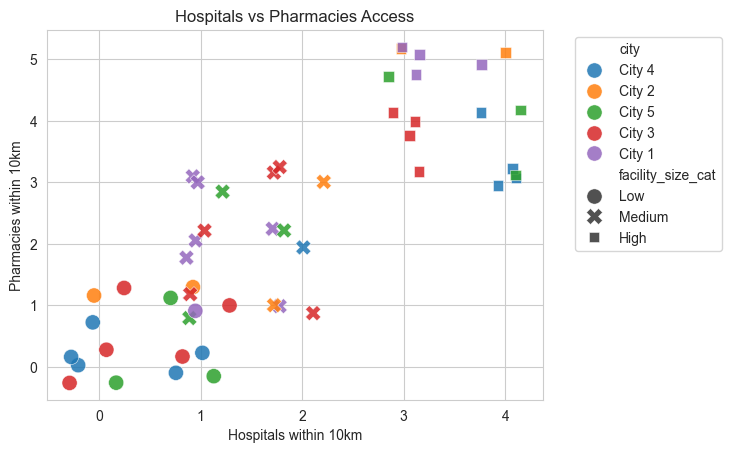

In [10]:
# Add jitter manually
rcq_df_jitter = rcq_df_sp.copy()
rcq_df_jitter["hospitals_10km"] += np.random.uniform(-0.3, 0.3, size=len(rcq_df))
rcq_df_jitter["pharmacies_10km"] += np.random.uniform(-0.3, 0.3, size=len(rcq_df))

sns.scatterplot(
    data=rcq_df_jitter,
    x="hospitals_10km",
    y="pharmacies_10km",
    hue="city",
    style="facility_size_cat",
    palette="tab10",
    s=120,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.4,
)

plt.title("Hospitals vs Pharmacies Access")
plt.xlabel("Hospitals within 10km")
plt.ylabel("Pharmacies within 10km")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

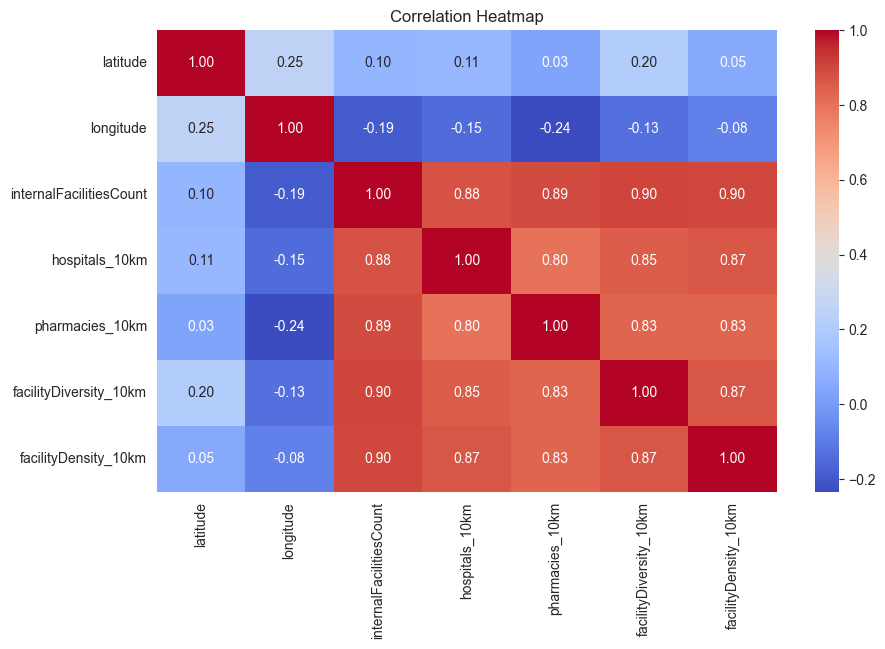

In [12]:
# Correlation heatmap of numeric columns.
numeric_cols = rcq_df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_cols.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


# Feature Selection
Since we do not have label for quality teir (premium, standard or basic), we use internalFacilitiesCount and facilityDiversity_10km as proxies.

1. Numeric feature selection

In [13]:
df_features = rcq_df.copy()

# Candidate list 
features = [
    "internalFacilitiesCount",
    "hospitals_10km",
    "pharmacies_10km",
    "facilityDiversity_10km",
    "facilityDensity_10km"
]

# Subset
df_features = df_features[features]
df_features.head()

,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
0,3,1,0,0.374488,0.177506
1,2,1,1,0.391903,0.108965
2,3,0,1,0.293552,0.076155
3,11,4,4,0.884502,0.697016
4,10,4,5,0.842611,0.568983


2. Correlation analysis

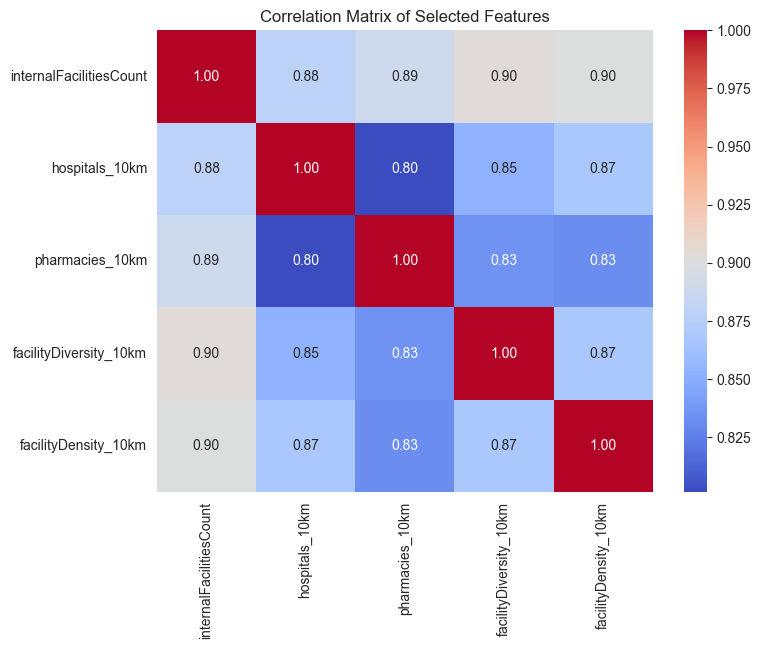

Correlation with internalFacilitiesCount:
internalFacilitiesCount    1.000000
facilityDiversity_10km     0.903568
facilityDensity_10km       0.900576
pharmacies_10km            0.889402
hospitals_10km             0.878828
Name: internalFacilitiesCount, dtype: float64


In [14]:
# Compute correlation matrix
corr_matrix = df_features.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Selected Features")
plt.show()

# Correlation with internalFacilitiesCount (proxy for quality)
print("Correlation with internalFacilitiesCount:")
print(corr_matrix["internalFacilitiesCount"].sort_values(ascending=False))

Conclusion: These 5 featues are highly informative for catpuring research center quality and surrounding ecosystem.

3. Variance check

In [15]:
variances = df_features.var()
print("Feature variances:")
print(variances)

Feature variances:
internalFacilitiesCount    9.902449
hospitals_10km             1.796327
pharmacies_10km            2.839184
facilityDiversity_10km     0.062256
facilityDensity_10km       0.033329
dtype: float64


Conclusion: Although High variance features are more discriminative for clustering, the low variance features can still be important because they measure structural quality.

# Discussion points:

Why were these features selected?

---
| Feature                     | Rationale                                                                                             |
| --------------------------- | ----------------------------------------------------------------------------------------------------- |
| **internalFacilitiesCount** | Direct indicator of research capacity and internal resources                                          |
| **hospitals_10km**          | Proximity to hospitals; access to healthcare support for research operations                         |
| **pharmacies_10km**         | Proximity to pharmacies; measures ecosystem support for biomedical or clinical research              |
| **facilityDiversity_10km**  | Diversity of nearby facilities; promotes interdisciplinary collaboration and higher quality outcomes |
| **facilityDensity_10km**    | Density of surrounding facilities; captures infrastructure richness around the center                |

Which features have the highest correlation with overall facility diversity or quality?

---

`facilityDiversity_10km` and `facilityDensity_10km` are almost as strongly correlated with internal facilities as pharmacies/hospitals. This shows the surrounding ecosystem is as important as the internal capacity.

Hospitals and pharmacies correlate strongly (~0.88–0.89), but slightly lower than diversity/density.

Overall insight:
Research centers with more internal facilities are almost always located in well-developed, dense, and diverse environments, with strong healthcare support.

# Clustering Model

1. Setup

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Copy the dataframe
rcq_df_clust = rcq_df.copy()

# Features selected based on correlation analysis
features = [
    "internalFacilitiesCount",
    "hospitals_10km",
    "pharmacies_10km",
    "facilityDiversity_10km",
    "facilityDensity_10km"
]

X = rcq_df_clust[features]

2. Standardise training data

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

3. Apply K-mean clustering (k=3)

In [18]:
# Initialize K-Means
rcq_segmentation_model = KMeans(n_clusters=3, random_state=42, n_init=10)

# Fit the model
rcq_df_clust['cluster'] = rcq_segmentation_model.fit_predict(X_scaled)

# Evaluate clustering quality
sil_score = silhouette_score(X_scaled, rcq_df_clust['cluster'])
print(f"Silhouette Score: {sil_score:.3f}")

Silhouette Score: 0.552


4. Map Cluster Numbers to Descriptive Labels

Since K-Means assigns arbitrary cluster numbers, we map them based on average internalFacilitiesCount per cluster:

In [20]:
# Compute cluster means for sorting
cluster_order = rcq_df_clust.groupby('cluster')['internalFacilitiesCount'].mean().sort_values(ascending=False).index

# Map cluster numbers to labels
cluster_labels = {cluster_order[0]: "Premium",
                  cluster_order[1]: "Standard",
                  cluster_order[2]: "Basic"}

rcq_df_clust['cluster_label'] = rcq_df_clust['cluster'].map(cluster_labels)

# View results
rcq_df_clust[['researchCenterName', 'internalFacilitiesCount', 'cluster', 'cluster_label']].head(10)

,researchCenterName,internalFacilitiesCount,cluster,cluster_label
0,Research Center 14,3,2,Basic
1,Research Center 40,2,2,Basic
2,Research Center 31,3,2,Basic
3,Research Center 46,11,1,Premium
4,Research Center 18,10,1,Premium
5,Research Center 49,4,0,Standard
6,Research Center 27,1,2,Basic
7,Research Center 26,8,1,Premium
8,Research Center 33,2,2,Basic
9,Research Center 20,2,2,Basic


5. Visualise clusters

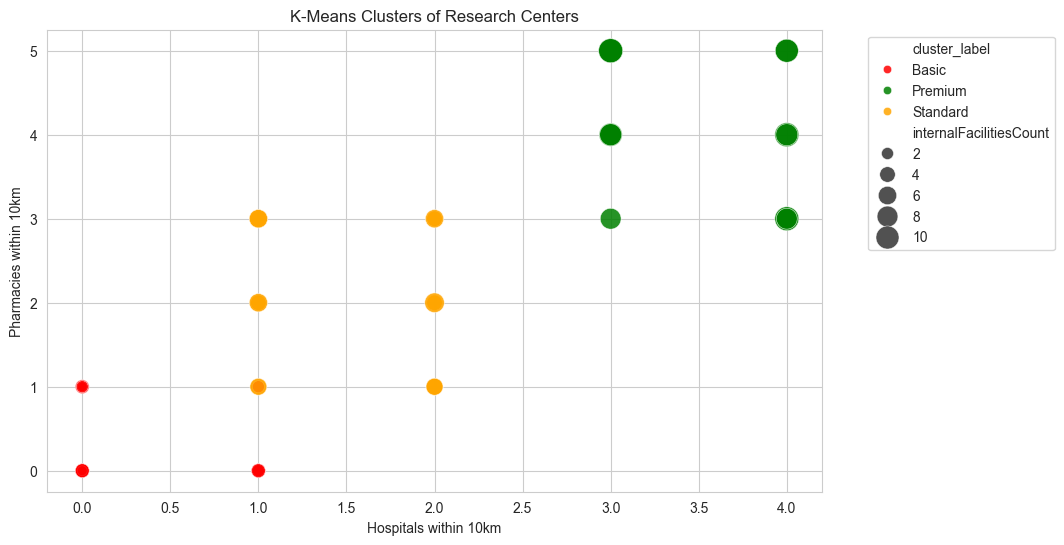

In [21]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=rcq_df_clust,
    x="hospitals_10km",
    y="pharmacies_10km",
    hue="cluster_label",
    size="internalFacilitiesCount",
    palette=["red", "green", "orange"],  # Premium=green, Standard=orange, Basic=red
    sizes=(50, 300),
    alpha=0.85,
    edgecolor="white",
    linewidth=0.4
)
plt.title("K-Means Clusters of Research Centers")
plt.xlabel("Hospitals within 10km")
plt.ylabel("Pharmacies within 10km")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

6. Model Interpretation

In [22]:
cluster_summary = rcq_df_clust.groupby('cluster_label')[features].mean().sort_values(by='internalFacilitiesCount', ascending=False)
cluster_summary

,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
cluster_label,,,,,
Premium,9.529412,3.470588,4.117647,0.850424,0.536852
Standard,4.941176,1.529412,2.058824,0.559935,0.289845
Basic,2.312500,0.500000,0.437500,0.279126,0.125271


7. Save model

In [23]:

joblib.dump(rcq_segmentation_model, "models/kmeans_research_centers.pkl")

['models/kmeans_research_centers.pkl']